In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys 

sys.path.append('../src/')

import matplotlib.pyplot as plt 
import torch
from rescue import utils, models

/media/sambhav/Windows/ml/RESCUE/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


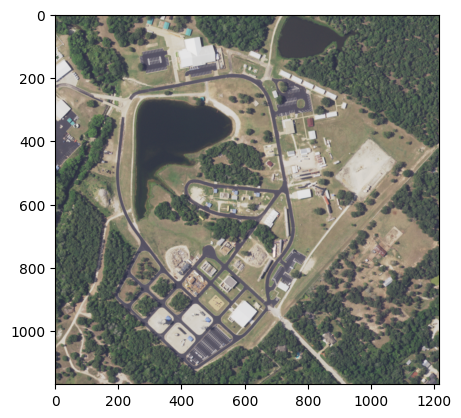

In [3]:
naip_path = '../data/disaster_city.nc'
rgb = utils.get_png_from_naip(naip_path)

plt.imshow(rgb)

In [4]:
# from huggingface_hub import snapshot_download
# snapshot_download(repo_id="facebook/sam3", local_dir=local_dir)
sam3_pred = models.sam3_predictor('../generated/sam3')

Loading weights: 100%|██████████| 1468/1468 [00:06<00:00, 213.12it/s]


In [5]:
# prompts = ['building']
# results = sam3_pred.pred_on_prompts_and_single_img(rgb, prompts, threshold=0.5, mask_threshold=0.5)
# masks, bboxes, scores, labels = utils.collate_sam3_results(results, prompts)

# plotted = utils.plot_sam3_detections(rgb, masks, bboxes, scores, labels)
# plt.figure(figsize = (10, 10))
# plt.imshow(plotted)

In [11]:
robot2keywords = {
'spot': ['road', 'pavement', 'sidewalk', 'concrete', 'asphalt', 'building', 'grass', 'dirt', 'barren', 'concrete'],
'small drone': ['building', 'canopy', 'trees', 'forest', 'roof', 'balcony', 'overhang', 'awning'],
'large drone': ['water', 'pond', 'lake', 'river']
}


In [43]:
robot2traverse = {}

for robot, keywords in robot2keywords.items():
    results = sam3_pred.pred_on_prompts_and_single_img(rgb, keywords, threshold=0.3, mask_threshold=0.5)
    masks, bboxes, scores, labels = utils.collate_sam3_results(results, keywords)

    robot2traverse[robot] = masks.max(axis = 0)
    # plotted = utils.plot_sam3_detections(rgb, masks, bboxes, scores, labels)
    # plt.figure(figsize = (10, 10))
    # plt.imshow(plotted)


In [ ]:
# plt.imshow()
robot2traverse['spot'].max()

np.int64(1)

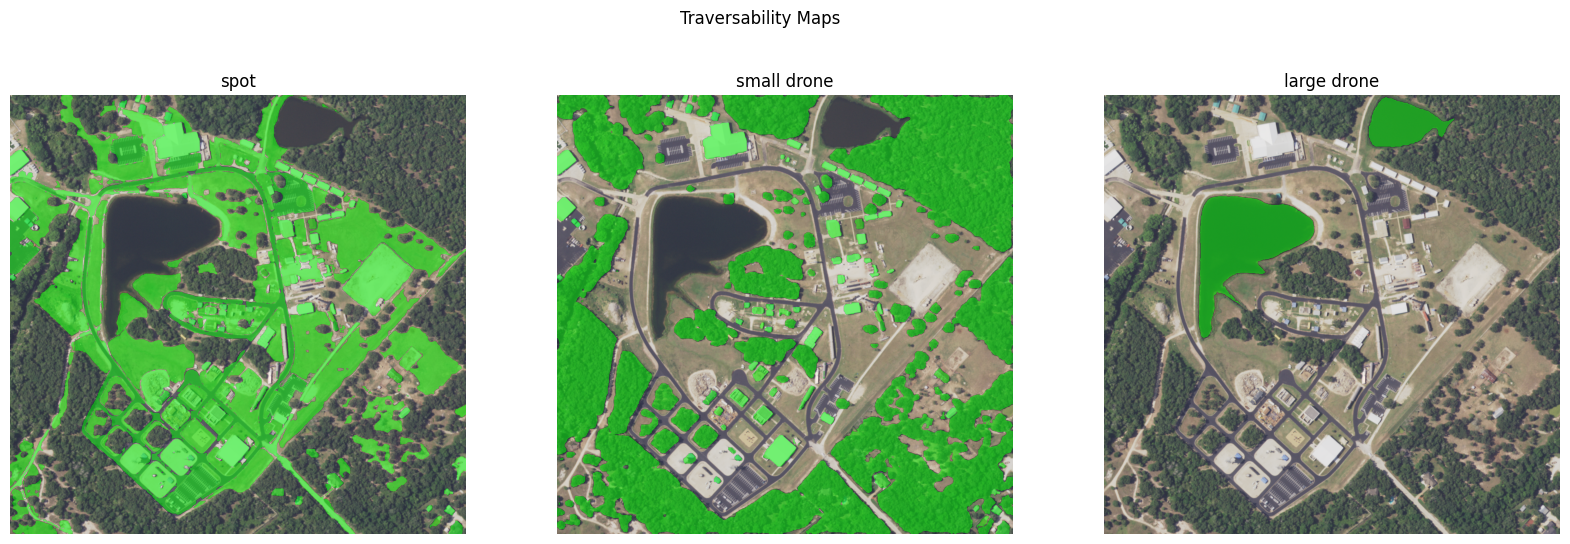

In [52]:
import numpy as np 
import cv2
from matplotlib.colors import ListedColormap

fig, axes = plt.subplots(nrows=1, ncols=len(robot2traverse), figsize = (20, 10))
green_cmap = ListedColormap(['lime'])

for i, (robot, mask) in enumerate(robot2traverse.items()):
    axes[i].imshow(rgb)

    transparent_mask = np.ma.masked_where(mask == 0, mask)
    axes[i].imshow(transparent_mask, cmap=green_cmap, alpha=0.5)

    axes[i].set_title(robot)
    axes[i].axis('off')

plt.suptitle("Traversability Maps", y = 0.8);